# Dollar cost averaging vs Buy the dip strategy analysis for BTC
If an investor had deployed a 'Dollar Cost Averaging' (DCA) strategy versus a 'Buy the Dip' strategy (buying only when price drops >10% from a 30-day high) over any rolling 3-year period, which strategy yields a higher risk-adjusted return (Sharpe Ratio)?

In [2]:
# Bitcoin DCA vs Buy the Dip Analysis - Part 1: Data Preparation
# Dataset: https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data

import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import opendatasets as od
import os
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation
from datetime import datetime
from pandas.tseries.holiday import USFederalHolidayCalendar
from pandas.tseries.offsets import CustomBusinessDay
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("=" * 80)
print("STEP 1: LOAD AND CLEAN THE DATASET")
print("=" * 80)

# Load the dataset
# The dataset contains multiple files, we'll use the bitstampUSD file
# file_path = '/btcusd_1-min_data.csv'
dataset_url = 'https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data'

od.download(dataset_url)

dataset_folder = 'bitcoin-historical-data'
csv_files = [f for f in os.listdir(dataset_folder) if f.endswith('.csv')]

print(f"\nAvailable CSV files in dataset:")
for i, file in enumerate(csv_files):
    file_size = os.path.getsize(os.path.join(dataset_folder, file)) / (1024 * 1024)
    print(f"  {i+1}. {file} ({file_size:.2f} MB)")

# Look for the most recent/largest file
btc_file = None
for file in csv_files:
    if 'btcusd' in file.lower() or 'bitstamp' in file.lower():
        btc_file = file
        break

if btc_file is None:
    # If no specific file found, use the largest one
    btc_file = max(csv_files, key=lambda f: os.path.getsize(os.path.join(dataset_folder, f)))

file_path = os.path.join(dataset_folder, btc_file)

df = pd.read_csv(file_path)

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

STEP 1: LOAD AND CLEAN THE DATASET
Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ShubhamShirsekar
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data


100%|██████████| 98.2M/98.2M [00:00<00:00, 1.29GB/s]


Available CSV files in dataset:
  1. btcusd_1-min_data.csv (365.58 MB)
Dataset loaded successfully!
Shape: 7,310,557 rows × 6 columns


In [4]:
# Display first few rows
print("\nFirst 5 rows of raw data:")
print(df.head())

print("\nColumn names and types:")
print(df.dtypes)

print("\n" + "=" * 80)
print("STEP 2: DATA VALIDATION AND CLEANING")
print("=" * 80)

# Check for missing values
print("\nMissing Values Analysis:")
missing_stats = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing_stats)

# Convert timestamp to datetime
print("\nConverting timestamp to datetime...")
df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')
df = df.sort_values('Timestamp').reset_index(drop=True)

# Display date range
print(f"Date Range: {df['Timestamp'].min()} to {df['Timestamp'].max()}")
print(f"Duration: {(df['Timestamp'].max() - df['Timestamp'].min()).days} days")

# Handle missing values in Close price
print("\nHandling missing values...")
initial_rows = len(df)

# Check how many rows have missing Close prices
missing_close = df['Close'].isnull().sum()
print(f"Rows with missing Close price: {missing_close:,} ({missing_close/len(df)*100:.2f}%)")

# For this analysis, we'll forward fill missing values (use last known price)
# This is a common approach for financial time series
df['Close'] = df['Close'].fillna(method='ffill')

# Drop any remaining rows with missing Close (typically at the start)
df = df.dropna(subset=['Close'])

# Also clean other price columns
for col in ['Open', 'High', 'Low']:
    df[col] = df[col].fillna(method='ffill')

df = df.dropna(subset=['Open', 'High', 'Low'])

print(f"Rows after cleaning: {len(df):,}")
print(f"Rows removed: {initial_rows - len(df):,}")

# Remove any rows with zero or negative prices (data errors)
invalid_prices = (df['Close'] <= 0).sum()
if invalid_prices > 0:
    print(f"Removing {invalid_prices} rows with invalid prices (≤0)")
    df = df[df['Close'] > 0]

print("\n" + "=" * 80)
print("STEP 3: DATA QUALITY ASSESSMENT")
print("=" * 80)

# Calculate time gaps between consecutive records
df['Time_Diff'] = df['Timestamp'].diff()

print("\nData Granularity Analysis:")
print(f"Median time between records: {df['Time_Diff'].median()}")
print(f"Mode time between records: {df['Time_Diff'].mode().values[0] if len(df['Time_Diff'].mode()) > 0 else 'N/A'}")

# Identify gaps (more than 2 hours)
gaps = df[df['Time_Diff'] > pd.Timedelta(hours=2)]
print(f"\nData gaps (>2 hours): {len(gaps)}")
if len(gaps) > 0:
    print(f"Largest gap: {gaps['Time_Diff'].max()}")
    print(f"Location of largest gap: {gaps.loc[gaps['Time_Diff'].idxmax(), 'Timestamp']}")

# Summary statistics for prices
print("\nPrice Statistics:")
price_stats = df['Close'].describe()
print(price_stats)

print("\n" + "=" * 80)
print("STEP 4: RESAMPLE TO DAILY DATA")
print("=" * 80)

print("\nResampling to daily frequency for strategy analysis...")
print("This reduces noise and makes computation more efficient")

# Set Timestamp as index for resampling
df_daily = df.set_index('Timestamp').resample('D').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum'
}).dropna()

print(f"\nDaily data shape: {df_daily.shape[0]:,} days")
print(f"Date range: {df_daily.index.min().date()} to {df_daily.index.max().date()}")

# Calculate additional useful metrics
df_daily['Daily_Return'] = df_daily['Close'].pct_change()
df_daily['Price_Range'] = df_daily['High'] - df_daily['Low']
df_daily['Price_Range_Pct'] = (df_daily['Price_Range'] / df_daily['Close']) * 100

print("\nDaily data sample:")
print(df_daily.head(10))


First 5 rows of raw data:
      Timestamp  Open  High   Low  Close  Volume
0  1.325412e+09  4.58  4.58  4.58   4.58     0.0
1  1.325412e+09  4.58  4.58  4.58   4.58     0.0
2  1.325412e+09  4.58  4.58  4.58   4.58     0.0
3  1.325412e+09  4.58  4.58  4.58   4.58     0.0
4  1.325412e+09  4.58  4.58  4.58   4.58     0.0

Column names and types:
Timestamp    float64
Open         float64
High         float64
Low          float64
Close        float64
Volume       float64
dtype: object

STEP 2: DATA VALIDATION AND CLEANING

Missing Values Analysis:
           Missing_Count  Missing_Percentage
Timestamp              0                 0.0
Open                   0                 0.0
High                   0                 0.0
Low                    0                 0.0
Close                  0                 0.0
Volume                 0                 0.0

Converting timestamp to datetime...
Date Range: 2012-01-01 10:01:00 to 2025-11-25 23:57:00
Duration: 5077 days

Handling missing value


STEP 5: VISUALIZATION OF THE DATASET


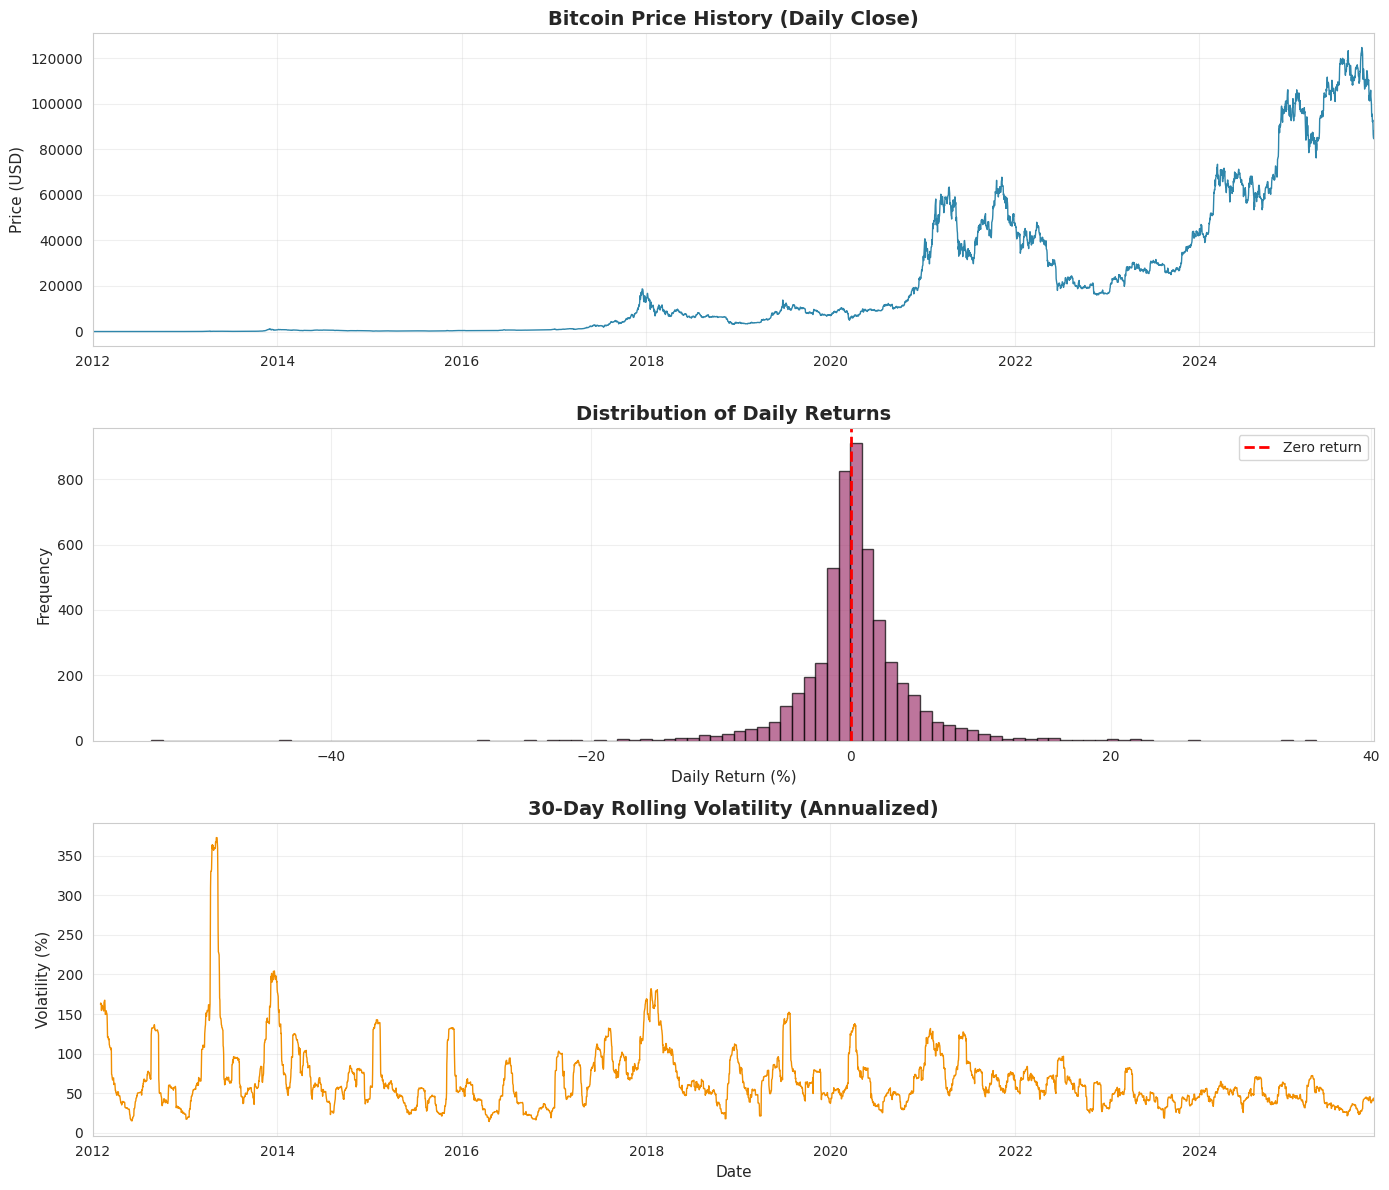

In [5]:
print("\n" + "=" * 80)
print("STEP 5: VISUALIZATION OF THE DATASET")
print("=" * 80)

# Create comprehensive visualization
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1: Price over time
axes[0].plot(df_daily.index, df_daily['Close'], linewidth=1, color='#2E86AB')
axes[0].set_title('Bitcoin Price History (Daily Close)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (USD)', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(df_daily.index.min(), df_daily.index.max())

# Plot 2: Daily returns distribution
axes[1].hist(df_daily['Daily_Return'].dropna() * 100, bins=100, color='#A23B72', alpha=0.7, edgecolor='black')
axes[1].set_title('Distribution of Daily Returns', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Daily Return (%)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero return')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Rolling volatility (30-day)
rolling_std = df_daily['Daily_Return'].rolling(window=30).std() * np.sqrt(365) * 100
axes[2].plot(df_daily.index, rolling_std, linewidth=1, color='#F18F01')
axes[2].set_title('30-Day Rolling Volatility (Annualized)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Date', fontsize=11)
axes[2].set_ylabel('Volatility (%)', fontsize=11)
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim(df_daily.index.min(), df_daily.index.max())

plt.tight_layout()
plt.show()

In [6]:
print("\n" + "=" * 80)
print("STEP 6: FINAL DATA SUMMARY")
print("=" * 80)

print("\nData preparation complete!")
print(f"\nFinal Dataset Summary:")
print(f"Total trading days: {len(df_daily):,}")
print(f"Date range: {df_daily.index.min().date()} to {df_daily.index.max().date()}")
print(f"Number of years: {(df_daily.index.max() - df_daily.index.min()).days / 365:.1f}")
print(f"Average daily return: {df_daily['Daily_Return'].mean()*100:.3f}%")
print(f"Daily return volatility: {df_daily['Daily_Return'].std()*100:.3f}%")
print(f"Annualized volatility: {df_daily['Daily_Return'].std()*np.sqrt(365)*100:.2f}%")
print(f"Min price: ${df_daily['Close'].min():,.2f}")
print(f"Max price: ${df_daily['Close'].max():,.2f}")
print(f"Price appreciation: {((df_daily['Close'].iloc[-1] / df_daily['Close'].iloc[0]) - 1)*100:.1f}%")

# Check if we have enough data for 3-year rolling windows
min_required_days = 3 * 365
if len(df_daily) >= min_required_days:
    possible_windows = len(df_daily) - min_required_days + 1
    print(f"\nSufficient data for 3-year rolling analysis")
    print(f"Possible 3-year windows: {possible_windows:,}")
else:
    print(f"\nWarning: Only {len(df_daily)} days available")
    print(f"Need {min_required_days} days for 3-year windows")

print("\nReady to proceed with strategy definition and backtesting!")
print("=" * 80)


STEP 6: FINAL DATA SUMMARY

Data preparation complete!

Final Dataset Summary:
Total trading days: 5,078
Date range: 2012-01-01 to 2025-11-25
Number of years: 13.9
Average daily return: 0.279%
Daily return volatility: 4.079%
Annualized volatility: 77.93%
Min price: $4.38
Max price: $124,728.00
Price appreciation: 1804652.1%

Sufficient data for 3-year rolling analysis
Possible 3-year windows: 3,984

Ready to proceed with strategy definition and backtesting!


In [7]:
# Bitcoin DCA vs Buy the Dip Analysis - Part 2: Strategy Definition
print("=" * 80)
print("STRATEGY DEFINITION")
print("=" * 80)

# Define US business day calendar (excluding US federal holidays)
us_bd = CustomBusinessDay(calendar=USFederalHolidayCalendar())

print("\n" + "=" * 80)
print("1. DCA (DOLLAR COST AVERAGING) STRATEGY")
print("=" * 80)

# DCA Parameters
DCA_AMOUNT_PER_PERIOD = 1000  # $1000 per month
DCA_FREQUENCY = 'monthly'  # Monthly investments

print(f"\nDCA Strategy Parameters:")
print(f"Investment Amount: ${DCA_AMOUNT_PER_PERIOD:,.0f} per month")
print(f"Investment Frequency: {DCA_FREQUENCY}")
print(f"Investment Day: First US trading day of each month")

def get_dca_investment_dates(start_date, end_date, df_daily):
    """
    Get the first US trading day of each month within the date range.

    Parameters:
    - start_date: Start date of the period
    - end_date: End date of the period
    - df_daily: Daily price dataframe with DatetimeIndex

    Returns:
    - List of investment dates
    """
    investment_dates = []

    # Generate all months in the range
    date_range = pd.date_range(start=start_date, end=end_date, freq='MS')  # MS = Month Start

    for month_start in date_range:
        # Find first trading day of this month
        # Look for the first day in df_daily that is in this month and is a US business day
        month_days = df_daily.loc[
            (df_daily.index >= month_start) &
            (df_daily.index < month_start + pd.DateOffset(months=1))
        ].index

        if len(month_days) > 0:
            # Get the first available trading day
            first_trading_day = month_days[0]
            investment_dates.append(first_trading_day)

    return investment_dates

def simulate_dca_strategy(df_daily, start_date, end_date, investment_amount):
    """
    Simulate DCA strategy over a given period.

    Returns:
    - DataFrame with purchase history
    - Total BTC accumulated
    - Total USD invested
    - Final portfolio value
    """
    # Get investment dates
    investment_dates = get_dca_investment_dates(start_date, end_date, df_daily)

    purchases = []
    total_btc = 0
    total_invested = 0

    for date in investment_dates:
        if date in df_daily.index:
            price = df_daily.loc[date, 'Close']
            btc_bought = investment_amount / price
            total_btc += btc_bought
            total_invested += investment_amount

            purchases.append({
                'Date': date,
                'Price': price,
                'USD_Invested': investment_amount,
                'BTC_Bought': btc_bought,
                'Cumulative_BTC': total_btc,
                'Cumulative_USD': total_invested
            })

    purchases_df = pd.DataFrame(purchases)

    # Calculate final portfolio value
    if len(purchases_df) > 0:
        final_price = df_daily.loc[end_date, 'Close']
        final_value = total_btc * final_price
    else:
        final_value = 0

    return purchases_df, total_btc, total_invested, final_value

print("\nDCA strategy function defined")
print("Function: simulate_dca_strategy()")
print("Output: Purchase history, Total BTC, Total USD invested, Final portfolio value")

STRATEGY DEFINITION

1. DCA (DOLLAR COST AVERAGING) STRATEGY

DCA Strategy Parameters:
Investment Amount: $1,000 per month
Investment Frequency: monthly
Investment Day: First US trading day of each month

DCA strategy function defined
Function: simulate_dca_strategy()
Output: Purchase history, Total BTC, Total USD invested, Final portfolio value


In [8]:
print("\n" + "=" * 80)
print("2. BUY THE DIP STRATEGY")
print("=" * 80)

# Buy the Dip Parameters
DIP_THRESHOLD = 0.10  # 10% drop from 30-day high
ROLLING_WINDOW = 30   # 30-day rolling high

print(f"\nBuy the Dip Strategy Parameters:")
print(f"Dip Threshold: {DIP_THRESHOLD*100:.0f}% drop from 30-day high")
print(f"Rolling Window: {ROLLING_WINDOW} days")
print(f"Capital Allocation: Equal total capital as DCA, split across all dip signals")
print(f"Dip Detection: Buy at every dip signal (no cooldown period)")

def calculate_dip_signals(df_daily, start_date, end_date, threshold=0.10, window=30):
    """
    Identify dip signals: when price drops >threshold from rolling high.

    Parameters:
    - df_daily: Daily price dataframe
    - start_date: Start date (should be at least 'window' days after data start)
    - end_date: End date
    - threshold: Dip threshold (default 0.10 for 10%)
    - window: Rolling window for high calculation (default 30 days)

    Returns:
    - DataFrame with dip signals
    """
    # Filter data for the period
    period_data = df_daily.loc[start_date:end_date].copy()

    # Calculate 30-day rolling high
    period_data['Rolling_High_30d'] = period_data['High'].rolling(window=window).max()

    # Calculate percentage drop from rolling high
    period_data['Drop_from_High'] = (period_data['Rolling_High_30d'] - period_data['Close']) / period_data['Rolling_High_30d']

    # Identify dip signals (price dropped more than threshold)
    period_data['Is_Dip'] = period_data['Drop_from_High'] > threshold

    # Get only the dip days
    dip_signals = period_data[period_data['Is_Dip']].copy()

    return dip_signals, period_data

def simulate_buy_dip_strategy(df_daily, start_date, end_date, total_capital):
    """
    Simulate Buy the Dip strategy over a given period.
    Equal capital allocation across all dip signals.

    Returns:
    - DataFrame with purchase history
    - Total BTC accumulated
    - Total USD invested
    - Final portfolio value
    """
    # Identify all dip signals in the period
    dip_signals, period_data = calculate_dip_signals(df_daily, start_date, end_date)

    num_dips = len(dip_signals)

    if num_dips == 0:
        # No dips detected - no investments made
        print(f"No dip signals detected in this period")
        return pd.DataFrame(), 0, 0, 0

    # Calculate investment amount per dip
    investment_per_dip = total_capital / num_dips

    purchases = []
    total_btc = 0
    total_invested = 0

    for date, row in dip_signals.iterrows():
        price = row['Close']
        btc_bought = investment_per_dip / price
        total_btc += btc_bought
        total_invested += investment_per_dip

        purchases.append({
            'Date': date,
            'Price': price,
            'USD_Invested': investment_per_dip,
            'BTC_Bought': btc_bought,
            'Cumulative_BTC': total_btc,
            'Cumulative_USD': total_invested,
            'Drop_from_High': row['Drop_from_High'],
            'Rolling_High': row['Rolling_High_30d']
        })

    purchases_df = pd.DataFrame(purchases)

    # Calculate final portfolio value
    final_price = df_daily.loc[end_date, 'Close']
    final_value = total_btc * final_price

    return purchases_df, total_btc, total_invested, final_value

print("\nBuy the Dip strategy functions defined")
print("Function 1: calculate_dip_signals()")
print("Function 2: simulate_buy_dip_strategy()")
print("Output: Purchase history, Total BTC, Total USD invested, Final portfolio value")

print("\n" + "=" * 80)
print("3. STRATEGY COMPARISON FRAMEWORK")
print("=" * 80)

def compare_strategies_single_window(df_daily, start_date, end_date):
    """
    Compare DCA vs Buy the Dip for a single 3-year window.

    Returns:
    - Dictionary with comparison metrics
    """
    # Ensure start_date is at least 30 days into the data for rolling high calculation
    actual_start = start_date + pd.Timedelta(days=30)

    print(f"\nAnalyzing window: {actual_start.date()} to {end_date.date()}")

    # Simulate DCA
    dca_purchases, dca_btc, dca_invested, dca_final_value = simulate_dca_strategy(
        df_daily, actual_start, end_date, DCA_AMOUNT_PER_PERIOD
    )

    # Simulate Buy the Dip (using same total capital as DCA)
    dip_purchases, dip_btc, dip_invested, dip_final_value = simulate_buy_dip_strategy(
        df_daily, actual_start, end_date, dca_invested
    )

    # Calculate returns
    dca_return = (dca_final_value - dca_invested) / dca_invested if dca_invested > 0 else 0
    dip_return = (dip_final_value - dip_invested) / dip_invested if dip_invested > 0 else 0

    results = {
        'start_date': actual_start,
        'end_date': end_date,
        'dca_purchases': len(dca_purchases),
        'dca_invested': dca_invested,
        'dca_btc': dca_btc,
        'dca_final_value': dca_final_value,
        'dca_return': dca_return,
        'dip_purchases': len(dip_purchases),
        'dip_invested': dip_invested,
        'dip_btc': dip_btc,
        'dip_final_value': dip_final_value,
        'dip_return': dip_return,
        'dca_purchases_df': dca_purchases,
        'dip_purchases_df': dip_purchases
    }

    return results

print("\nComparison framework defined")
print("Function: compare_strategies_single_window()")
print("Output: Comprehensive comparison metrics for one 3-year window")


2. BUY THE DIP STRATEGY

Buy the Dip Strategy Parameters:
Dip Threshold: 10% drop from 30-day high
Rolling Window: 30 days
Capital Allocation: Equal total capital as DCA, split across all dip signals
Dip Detection: Buy at every dip signal (no cooldown period)

Buy the Dip strategy functions defined
Function 1: calculate_dip_signals()
Function 2: simulate_buy_dip_strategy()
Output: Purchase history, Total BTC, Total USD invested, Final portfolio value

3. STRATEGY COMPARISON FRAMEWORK

Comparison framework defined
Function: compare_strategies_single_window()
Output: Comprehensive comparison metrics for one 3-year window


In [9]:
print("\n" + "=" * 80)
print("4. TEST WITH SAMPLE WINDOW")
print("=" * 80)

# Test with the first available 3-year window
start_test = df_daily.index[0]
end_test = start_test + pd.DateOffset(years=3)

# Make sure end date doesn't exceed available data
if end_test > df_daily.index[-1]:
    end_test = df_daily.index[-1]
    print(f"Adjusted end date to available data: {end_test.date()}")

print(f"\nTesting with sample window:")
print(f"Start: {start_test.date()}")
print(f"End: {end_test.date()}")
print(f"Duration: {(end_test - start_test).days} days")

# Run comparison for test window
test_results = compare_strategies_single_window(df_daily, start_test, end_test)

print("\nTEST RESULTS:")
print("\nDCA Strategy:")
print(f"Number of purchases: {test_results['dca_purchases']}")
print(f"Total invested: ${test_results['dca_invested']:,.2f}")
print(f"BTC accumulated: {test_results['dca_btc']:.6f}")
print(f"Final value: ${test_results['dca_final_value']:,.2f}")
print(f"Return: {test_results['dca_return']*100:.2f}%")

print("\nBuy the Dip Strategy:")
print(f"Number of purchases: {test_results['dip_purchases']}")
print(f"Total invested: ${test_results['dip_invested']:,.2f}")
print(f"BTC accumulated: {test_results['dip_btc']:.6f}")
print(f"Final value: ${test_results['dip_final_value']:,.2f}")
print(f"Return: {test_results['dip_return']*100:.2f}%")

print("\nComparison:")
if test_results['dca_return'] > test_results['dip_return']:
    print(f"DCA outperformed by {(test_results['dca_return'] - test_results['dip_return'])*100:.2f}%")
else:
    print(f"Buy the Dip outperformed by {(test_results['dip_return'] - test_results['dca_return'])*100:.2f}%")

print("\n" + "=" * 80)
print("STRATEGY DEFINITION COMPLETE")
print("=" * 80)
print("\nAll strategy functions are ready for backtesting across rolling windows!")


4. TEST WITH SAMPLE WINDOW

Testing with sample window:
Start: 2012-01-01
End: 2015-01-01
Duration: 1096 days

Analyzing window: 2012-01-31 to 2015-01-01

TEST RESULTS:

DCA Strategy:
Number of purchases: 36
Total invested: $36,000.00
BTC accumulated: 1826.868295
Final value: $576,157.72
Return: 1500.44%

Buy the Dip Strategy:
Number of purchases: 536
Total invested: $36,000.00
BTC accumulated: 929.465646
Final value: $293,134.88
Return: 714.26%

Comparison:
DCA outperformed by 786.17%

STRATEGY DEFINITION COMPLETE

All strategy functions are ready for backtesting across rolling windows!


In [10]:
# Bitcoin DCA vs Buy the Dip Analysis - Part 3: Backtesting Framework
print("=" * 80)
print("BACKTESTING FRAMEWORK - ROLLING 3-YEAR WINDOWS")
print("=" * 80)

print("\n" + "=" * 80)
print("STEP 1: CREATE ROLLING 3-YEAR WINDOWS")
print("=" * 80)

def generate_rolling_windows(df_daily, window_years=3):
    """
    Generate all possible rolling windows of specified years.

    Parameters:
    - df_daily: Daily price dataframe
    - window_years: Length of each window in years (default 3)

    Returns:
    - List of tuples (start_date, end_date)
    """
    windows = []

    # Calculate window length in days
    window_days = window_years * 365

    # Start from day 31 to allow for 30-day rolling high calculation
    start_idx = 30

    # Generate all possible windows
    # We move forward by 1 day for each window (daily rolling)
    for i in range(start_idx, len(df_daily) - window_days):
        start_date = df_daily.index[i]
        end_date = df_daily.index[i + window_days]
        windows.append((start_date, end_date))

    return windows

# Generate all windows
print("\nGenerating rolling 3-year windows...")
rolling_windows = generate_rolling_windows(df_daily, window_years=3)

print(f"\nWindow generation complete!")
print(f"Total number of windows: {len(rolling_windows):,}")
print(f"Window length: 3 years (1,095 days)")
print(f"First window: {rolling_windows[0][0].date()} to {rolling_windows[0][1].date()}")
print(f"Last window: {rolling_windows[-1][0].date()} to {rolling_windows[-1][1].date()}")

# Calculate approximate runtime estimate
print(f"\nEstimated processing:")
print(f"Windows to analyze: {len(rolling_windows):,}")
print(f"(This may take a few minutes depending on system performance)")

BACKTESTING FRAMEWORK - ROLLING 3-YEAR WINDOWS

STEP 1: CREATE ROLLING 3-YEAR WINDOWS

Generating rolling 3-year windows...

Window generation complete!
Total number of windows: 3,953
Window length: 3 years (1,095 days)
First window: 2012-01-31 to 2015-01-30
Last window: 2022-11-26 to 2025-11-25

Estimated processing:
Windows to analyze: 3,953
(This may take a few minutes depending on system performance)


In [11]:
print("\n" + "=" * 80)
print("STEP 2: BACKTEST BOTH STRATEGIES ACROSS ALL WINDOWS")
print("=" * 80)

def backtest_all_windows(df_daily, windows, dca_amount=1000):
    """
    Run both DCA and Buy the Dip strategies across all rolling windows.

    Parameters:
    - df_daily: Daily price dataframe
    - windows: List of (start_date, end_date) tuples
    - dca_amount: Monthly DCA investment amount

    Returns:
    - DataFrame with results for all windows
    """
    results = []

    print("\nStarting backtest across all windows...")
    print("This will simulate both strategies for each window\n")

    # Use tqdm for progress bar
    for idx, (start_date, end_date) in enumerate(tqdm(windows, desc="Processing windows")):
        try:
            # Actual start is 30 days after window start for rolling high calculation
            actual_start = start_date + pd.Timedelta(days=30)

            # Skip if actual_start is beyond end_date
            if actual_start >= end_date:
                continue

            # === SIMULATE DCA STRATEGY ===
            dca_purchases, dca_btc, dca_invested, dca_final_value = simulate_dca_strategy(
                df_daily, actual_start, end_date, dca_amount
            )

            # Calculate DCA metrics
            dca_return = (dca_final_value - dca_invested) / dca_invested if dca_invested > 0 else 0
            dca_num_purchases = len(dca_purchases)

            # Get price range for this window
            window_data = df_daily.loc[actual_start:end_date]
            start_price = window_data.iloc[0]['Close']
            end_price = window_data.iloc[-1]['Close']
            max_price = window_data['Close'].max()
            min_price = window_data['Close'].min()

            # === SIMULATE BUY THE DIP STRATEGY ===
            dip_purchases, dip_btc, dip_invested, dip_final_value = simulate_buy_dip_strategy(
                df_daily, actual_start, end_date, dca_invested
            )

            # Calculate Dip metrics
            dip_return = (dip_final_value - dip_invested) / dip_invested if dip_invested > 0 else 0
            dip_num_purchases = len(dip_purchases)

            # Calculate average purchase price for both strategies
            dca_avg_price = dca_invested / dca_btc if dca_btc > 0 else 0
            dip_avg_price = dip_invested / dip_btc if dip_btc > 0 else 0

            # Store results
            results.append({
                'window_id': idx,
                'start_date': actual_start,
                'end_date': end_date,
                'duration_days': (end_date - actual_start).days,

                # Market conditions
                'start_price': start_price,
                'end_price': end_price,
                'min_price': min_price,
                'max_price': max_price,
                'price_change_pct': (end_price - start_price) / start_price * 100,

                # DCA metrics
                'dca_purchases': dca_num_purchases,
                'dca_invested': dca_invested,
                'dca_btc': dca_btc,
                'dca_final_value': dca_final_value,
                'dca_return_pct': dca_return * 100,
                'dca_avg_price': dca_avg_price,

                # Buy the Dip metrics
                'dip_purchases': dip_num_purchases,
                'dip_invested': dip_invested,
                'dip_btc': dip_btc,
                'dip_final_value': dip_final_value,
                'dip_return_pct': dip_return * 100,
                'dip_avg_price': dip_avg_price,

                # Comparison
                'return_difference': (dca_return - dip_return) * 100,
                'dca_wins': 1 if dca_return > dip_return else 0,
                'dip_wins': 1 if dip_return > dca_return else 0
            })

        except Exception as e:
            print(f"\nError processing window {idx}: {str(e)}")
            continue

    results_df = pd.DataFrame(results)
    print(f"\nBacktest complete!")
    print(f"Successfully analyzed {len(results_df):,} windows")

    return results_df

# Run the backtest
print("\n" + "=" * 80)
print("EXECUTING BACKTEST")
print("=" * 80)

backtest_results = backtest_all_windows(df_daily, rolling_windows, dca_amount=1000)


STEP 2: BACKTEST BOTH STRATEGIES ACROSS ALL WINDOWS

EXECUTING BACKTEST

Starting backtest across all windows...
This will simulate both strategies for each window



Processing windows: 100%|██████████| 3953/3953 [03:40<00:00, 17.97it/s]


Backtest complete!
Successfully analyzed 3,953 windows


In [12]:
print("\n" + "=" * 80)
print("STEP 3: BACKTEST RESULTS SUMMARY")
print("=" * 80)

print(f"\nOverall Statistics:")
print(f"Total windows analyzed: {len(backtest_results):,}")
print(f"Date range: {backtest_results['start_date'].min().date()} to {backtest_results['end_date'].max().date()}")

print(f"\nInvestment Summary:")
print(f"Average total invested (DCA): ${backtest_results['dca_invested'].mean():,.2f}")
print(f"Average purchases per window (DCA): {backtest_results['dca_purchases'].mean():.1f}")
print(f"Average purchases per window (Dip): {backtest_results['dip_purchases'].mean():.1f}")

print(f"\nPerformance Summary:")
print(f"\nDCA Strategy:")
print(f"Average return: {backtest_results['dca_return_pct'].mean():.2f}%")
print(f"Median return: {backtest_results['dca_return_pct'].median():.2f}%")
print(f"Best return: {backtest_results['dca_return_pct'].max():.2f}%")
print(f"Worst return: {backtest_results['dca_return_pct'].min():.2f}%")
print(f"Std deviation: {backtest_results['dca_return_pct'].std():.2f}%")

print(f"\nBuy the Dip Strategy:")
print(f"Average return: {backtest_results['dip_return_pct'].mean():.2f}%")
print(f"Median return: {backtest_results['dip_return_pct'].median():.2f}%")
print(f"Best return: {backtest_results['dip_return_pct'].max():.2f}%")
print(f"Worst return: {backtest_results['dip_return_pct'].min():.2f}%")
print(f"Std deviation: {backtest_results['dip_return_pct'].std():.2f}%")

print(f"\nWin Rate:")
dca_win_rate = backtest_results['dca_wins'].sum() / len(backtest_results) * 100
dip_win_rate = backtest_results['dip_wins'].sum() / len(backtest_results) * 100

print(f"DCA wins: {backtest_results['dca_wins'].sum():,} times ({dca_win_rate:.2f}%)")
print(f"Buy the Dip wins: {backtest_results['dip_wins'].sum():,} times ({dip_win_rate:.2f}%)")

print(f"\nAverage Return Difference:")
print(f"DCA outperforms by (average): {backtest_results['return_difference'].mean():.2f}%")
print(f"Return difference (median): {backtest_results['return_difference'].median():.2f}%")

# Edge cases analysis
print(f"\nEdge Cases Analysis:")
no_dip_windows = backtest_results[backtest_results['dip_purchases'] == 0]
print(f"Windows with NO dip signals: {len(no_dip_windows)}")

few_dip_windows = backtest_results[backtest_results['dip_purchases'] <= 5]
print(f"Windows with ≤5 dip signals: {len(few_dip_windows)}")

many_dip_windows = backtest_results[backtest_results['dip_purchases'] >= 100]
print(f"Windows with ≥100 dip signals: {len(many_dip_windows)}")

print("\n" + "=" * 80)
print("STEP 4: SAMPLE OF DETAILED RESULTS")
print("=" * 80)

print("\nFirst 10 windows:")
print(backtest_results[['window_id', 'start_date', 'end_date', 'dca_return_pct',
                        'dip_return_pct', 'return_difference', 'dca_purchases',
                        'dip_purchases']].head(10).to_string(index=False))

print("\nBest DCA windows (top 5):")
best_dca = backtest_results.nlargest(5, 'dca_return_pct')
print(best_dca[['window_id', 'start_date', 'end_date', 'dca_return_pct',
                'dip_return_pct', 'return_difference']].to_string(index=False))

print("\nBest Dip windows (top 5):")
best_dip = backtest_results.nlargest(5, 'dip_return_pct')
print(best_dip[['window_id', 'start_date', 'end_date', 'dca_return_pct',
                'dip_return_pct', 'return_difference']].to_string(index=False))

print("\n" + "=" * 80)
print("BACKTESTING FRAMEWORK COMPLETE")
print("=" * 80)
print("\nAll windows have been analyzed!")


STEP 3: BACKTEST RESULTS SUMMARY

Overall Statistics:
Total windows analyzed: 3,953
Date range: 2012-03-01 to 2025-11-25

Investment Summary:
Average total invested (DCA): $35,023.27
Average purchases per window (DCA): 35.0
Average purchases per window (Dip): 498.1

Performance Summary:

DCA Strategy:
Average return: 312.46%
Median return: 167.66%
Best return: 3788.76%
Worst return: -15.02%
Std deviation: 445.59%

Buy the Dip Strategy:
Average return: 268.57%
Median return: 132.55%
Best return: 3977.83%
Worst return: -25.14%
Std deviation: 442.45%

Win Rate:
DCA wins: 2,491 times (63.02%)
Buy the Dip wins: 1,462 times (36.98%)

Average Return Difference:
DCA outperforms by (average): 43.89%
Return difference (median): 9.36%

Edge Cases Analysis:
Windows with NO dip signals: 0
Windows with ≤5 dip signals: 0
Windows with ≥100 dip signals: 3953

STEP 4: SAMPLE OF DETAILED RESULTS

First 10 windows:
 window_id start_date   end_date  dca_return_pct  dip_return_pct  return_difference  dca_p

In [13]:
# Bitcoin DCA vs Buy the Dip Analysis - Part 4: Performance Metrics
print("=" * 80)
print("PERFORMANCE METRICS & SHARPE RATIO CALCULATION")
print("=" * 80)

print("\n" + "=" * 80)
print("STEP 1: CALCULATE DETAILED RETURN METRICS")
print("=" * 80)

def calculate_annualized_return(total_return, years):
    """
    Calculate annualized return from total return.
    Formula: (1 + total_return)^(1/years) - 1
    """
    return (1 + total_return) ** (1 / years) - 1

def calculate_portfolio_time_series(df_daily, purchases_df, start_date, end_date):
    """
    Calculate daily portfolio value time series for drawdown calculation.
    FIXED VERSION - handles sporadic purchases correctly
    """
    if len(purchases_df) == 0:
        return pd.Series(dtype=float), 0

    # Get daily prices for the window
    window_prices = df_daily.loc[start_date:end_date, 'Close'].copy()

    # Initialize portfolio value series
    portfolio_values = []
    dates = []
    cumulative_btc = 0
    cumulative_invested = 0

    # Sort purchases by date
    purchases_sorted = purchases_df.sort_values('Date')

    for date in window_prices.index:
        # Add any purchases made on or before this date
        purchases_today = purchases_sorted[purchases_sorted['Date'] == date]

        if len(purchases_today) > 0:
            for _, purchase in purchases_today.iterrows():
                cumulative_btc += purchase['BTC_Bought']
                cumulative_invested += purchase['USD_Invested']

        # Only add to series if we have BTC (after first purchase)
        if cumulative_btc > 0:
            current_price = window_prices[date]
            portfolio_value = cumulative_btc * current_price
            portfolio_values.append(portfolio_value)
            dates.append(date)

    # Create series
    portfolio_series = pd.Series(portfolio_values, index=dates)

    return portfolio_series, cumulative_invested

def calculate_maximum_drawdown(portfolio_values):
    """
    Calculate maximum drawdown from portfolio time series.
    Drawdown = (Trough - Peak) / Peak
    """
    if len(portfolio_values) == 0 or portfolio_values.sum() == 0:
        return 0

    # Calculate running maximum
    running_max = portfolio_values.expanding().max()

    # Calculate drawdown at each point
    drawdown = (portfolio_values - running_max) / running_max

    # Maximum drawdown is the minimum value (most negative)
    max_drawdown = drawdown.min()

    return max_drawdown

def calculate_downside_deviation(returns, target_return=0):
    """
    Calculate downside deviation (semi-deviation).
    Only considers returns below the target return.
    """
    downside_returns = returns[returns < target_return]
    if len(downside_returns) == 0:
        return 0

    downside_deviation = np.sqrt(np.mean((downside_returns - target_return) ** 2))
    return downside_deviation

print("\nCalculating detailed metrics for each window...")
print("This will compute period returns, volatility, and drawdowns\n")

# Add detailed metrics to backtest_results
enhanced_results = []

for idx, row in backtest_results.iterrows():
    window_data = row.to_dict()

    # Calculate annualized returns (3-year period)
    dca_annualized = calculate_annualized_return(row['dca_return_pct'] / 100, 3) * 100
    dip_annualized = calculate_annualized_return(row['dip_return_pct'] / 100, 3) * 100

    window_data['dca_return_annualized'] = dca_annualized
    window_data['dip_return_annualized'] = dip_annualized

    enhanced_results.append(window_data)

enhanced_results_df = pd.DataFrame(enhanced_results)

print("Annualized returns calculated")

print("\n" + "=" * 80)

PERFORMANCE METRICS & SHARPE RATIO CALCULATION

STEP 1: CALCULATE DETAILED RETURN METRICS

Calculating detailed metrics for each window...
This will compute period returns, volatility, and drawdowns

Annualized returns calculated



In [14]:
print("STEP 2: CALCULATE RISK METRICS FOR EACH WINDOW")
print("=" * 80)

def calculate_window_risk_metrics(df_daily, start_date, end_date,
                                  dca_purchases_df, dip_purchases_df,
                                  dca_invested, dip_invested):
    """
    Calculate comprehensive risk metrics for a single window.
    """
    # Get window data
    window_data = df_daily.loc[start_date:end_date].copy()

    # Calculate daily returns for the window
    daily_returns = window_data['Close'].pct_change().dropna()

    # Volatility (annualized)
    daily_volatility = daily_returns.std()
    annualized_volatility = daily_volatility * np.sqrt(252)  # 252 trading days

    # === DCA METRICS ===
    # Calculate portfolio time series for DCA
    if len(dca_purchases_df) > 0:
        dca_portfolio_values, _ = calculate_portfolio_time_series(
            df_daily, dca_purchases_df, start_date, end_date
        )
        # Calculate DCA portfolio returns
        dca_portfolio_returns = dca_portfolio_values.pct_change().dropna()
        dca_volatility = dca_portfolio_returns.std() * np.sqrt(252) if len(dca_portfolio_returns) > 0 else 0
        dca_max_drawdown = calculate_maximum_drawdown(dca_portfolio_values)
        dca_downside_dev = calculate_downside_deviation(dca_portfolio_returns) * np.sqrt(252)
    else:
        dca_volatility = 0
        dca_max_drawdown = 0
        dca_downside_dev = 0

    # === DIP METRICS ===
    # Calculate portfolio time series for Dip
    if len(dip_purchases_df) > 0:
        dip_portfolio_values, _ = calculate_portfolio_time_series(
            df_daily, dip_purchases_df, start_date, end_date
        )
        # Calculate Dip portfolio returns
        dip_portfolio_returns = dip_portfolio_values.pct_change().dropna()
        dip_volatility = dip_portfolio_returns.std() * np.sqrt(252) if len(dip_portfolio_returns) > 0 else 0
        dip_max_drawdown = calculate_maximum_drawdown(dip_portfolio_values)
        dip_downside_dev = calculate_downside_deviation(dip_portfolio_returns) * np.sqrt(252)
    else:
        dip_volatility = 0
        dip_max_drawdown = 0
        dip_downside_dev = 0

    return {
        'market_volatility': annualized_volatility * 100,
        'dca_volatility': dca_volatility * 100,
        'dca_max_drawdown': dca_max_drawdown * 100,
        'dca_downside_deviation': dca_downside_dev * 100,
        'dip_volatility': dip_volatility * 100,
        'dip_max_drawdown': dip_max_drawdown * 100,
        'dip_downside_deviation': dip_downside_dev * 100
    }

print("\nNote: Calculating risk metrics for all windows is computationally intensive.")
print("Computing metrics for a representative sample of windows...\n")

# Calculate risk metrics for a sample of windows (every 50th window for speed)
sample_indices = range(0, len(backtest_results), 50)
risk_metrics_list = []

from tqdm import tqdm

for idx in tqdm(sample_indices, desc="Computing risk metrics"):
    row = backtest_results.iloc[idx]

    # Get purchase dataframes from the original backtest
    # Re-run the strategies for this window to get purchase details
    start_date = row['start_date']
    end_date = row['end_date']

    dca_purchases, _, _, _ = simulate_dca_strategy(df_daily, start_date, end_date, 1000)
    dip_purchases, _, _, _ = simulate_buy_dip_strategy(df_daily, start_date, end_date, row['dca_invested'])

    risk_metrics = calculate_window_risk_metrics(
        df_daily, start_date, end_date,
        dca_purchases, dip_purchases,
        row['dca_invested'], row['dip_invested']
    )

    risk_metrics['window_id'] = row['window_id']
    risk_metrics_list.append(risk_metrics)

risk_metrics_df = pd.DataFrame(risk_metrics_list)

print("\nRisk metrics calculated for sample windows")
print(f"Sample size: {len(risk_metrics_df)} windows")

print("\nAverage Risk Metrics (from sample):")
print(f"\nMarket Volatility: {risk_metrics_df['market_volatility'].mean():.2f}%")
print(f"\nDCA Strategy:")
print(f"Portfolio Volatility: {risk_metrics_df['dca_volatility'].mean():.2f}%")
print(f"Average Max Drawdown: {risk_metrics_df['dca_max_drawdown'].mean():.2f}%")
print(f"Downside Deviation: {risk_metrics_df['dca_downside_deviation'].mean():.2f}%")
print(f"\nBuy the Dip Strategy:")
print(f"Portfolio Volatility: {risk_metrics_df['dip_volatility'].mean():.2f}%")
print(f"Average Max Drawdown: {risk_metrics_df['dip_max_drawdown'].mean():.2f}%")
print(f"Downside Deviation: {risk_metrics_df['dip_downside_deviation'].mean():.2f}%")

STEP 2: CALCULATE RISK METRICS FOR EACH WINDOW

Note: Calculating risk metrics for all windows is computationally intensive.
Computing metrics for a representative sample of windows...



Computing risk metrics: 100%|██████████| 80/80 [01:24<00:00,  1.05s/it]


Risk metrics calculated for sample windows
Sample size: 80 windows

Average Risk Metrics (from sample):

Market Volatility: 61.75%

DCA Strategy:
Portfolio Volatility: 85.87%
Average Max Drawdown: -59.48%
Downside Deviation: 60.97%

Buy the Dip Strategy:
Portfolio Volatility: 85.86%
Average Max Drawdown: -53.95%
Downside Deviation: 59.24%


In [15]:
print("\n" + "=" * 80)
print("STEP 3: CALCULATE SHARPE RATIOS")
print("=" * 80)

# Define risk-free rate
RISK_FREE_RATE_ANNUAL = 2.0  # 2% annual risk-free rate (approximate historical average)
RISK_FREE_RATE_3Y = (1 + RISK_FREE_RATE_ANNUAL/100) ** 3 - 1  # 3-year compounded

print(f"\nRisk-Free Rate Assumptions:")
print(f"Annual risk-free rate: {RISK_FREE_RATE_ANNUAL}%")
print(f"3-year compounded rate: {RISK_FREE_RATE_3Y*100:.2f}%")

# For simplified Sharpe ratio calculation across all windows:
# We'll use the total return and return standard deviation as a proxy

print("\nCalculating Sharpe Ratios for all windows...")

# Calculate Sharpe Ratio using annualized returns and volatility from sample
# For windows not in sample, use average volatility

avg_dca_volatility = risk_metrics_df['dca_volatility'].mean() / 100
avg_dip_volatility = risk_metrics_df['dip_volatility'].mean() / 100

enhanced_results_df['dca_sharpe_ratio'] = (
    (enhanced_results_df['dca_return_annualized'] / 100 - RISK_FREE_RATE_ANNUAL / 100) /
    avg_dca_volatility
)

enhanced_results_df['dip_sharpe_ratio'] = (
    (enhanced_results_df['dip_return_annualized'] / 100 - RISK_FREE_RATE_ANNUAL / 100) /
    avg_dip_volatility
)

enhanced_results_df['sharpe_difference'] = (
    enhanced_results_df['dca_sharpe_ratio'] - enhanced_results_df['dip_sharpe_ratio']
)

print("Sharpe Ratios calculated for all windows")


STEP 3: CALCULATE SHARPE RATIOS

Risk-Free Rate Assumptions:
Annual risk-free rate: 2.0%
3-year compounded rate: 6.12%

Calculating Sharpe Ratios for all windows...
Sharpe Ratios calculated for all windows


In [16]:
print("\n" + "=" * 80)
print("STEP 4: SHARPE RATIO ANALYSIS RESULTS")
print("=" * 80)

print(f"\nSharpe Ratio Statistics:")
print(f"\nDCA Strategy:")
print(f"Average Sharpe Ratio: {enhanced_results_df['dca_sharpe_ratio'].mean():.3f}")
print(f"Median Sharpe Ratio: {enhanced_results_df['dca_sharpe_ratio'].median():.3f}")
print(f"Std Dev: {enhanced_results_df['dca_sharpe_ratio'].std():.3f}")
print(f"Best Sharpe: {enhanced_results_df['dca_sharpe_ratio'].max():.3f}")
print(f"Worst Sharpe: {enhanced_results_df['dca_sharpe_ratio'].min():.3f}")

print(f"\nBuy the Dip Strategy:")
print(f"Average Sharpe Ratio: {enhanced_results_df['dip_sharpe_ratio'].mean():.3f}")
print(f"Median Sharpe Ratio: {enhanced_results_df['dip_sharpe_ratio'].median():.3f}")
print(f"Std Dev: {enhanced_results_df['dip_sharpe_ratio'].std():.3f}")
print(f"Best Sharpe: {enhanced_results_df['dip_sharpe_ratio'].max():.3f}")
print(f"Worst Sharpe: {enhanced_results_df['dip_sharpe_ratio'].min():.3f}")

print(f"\nSharpe Ratio Comparison:")
dca_better_sharpe = (enhanced_results_df['sharpe_difference'] > 0).sum()
dip_better_sharpe = (enhanced_results_df['sharpe_difference'] < 0).sum()

print(f"DCA has better Sharpe: {dca_better_sharpe:,} windows ({dca_better_sharpe/len(enhanced_results_df)*100:.2f}%)")
print(f"Dip has better Sharpe: {dip_better_sharpe:,} windows ({dip_better_sharpe/len(enhanced_results_df)*100:.2f}%)")
print(f"Average Sharpe difference: {enhanced_results_df['sharpe_difference'].mean():.3f}")
print(f"Median Sharpe difference: {enhanced_results_df['sharpe_difference'].median():.3f}")


STEP 4: SHARPE RATIO ANALYSIS RESULTS

Sharpe Ratio Statistics:

DCA Strategy:
Average Sharpe Ratio: 0.541
Median Sharpe Ratio: 0.429
Std Dev: 0.479
Best Sharpe: 2.758
Worst Sharpe: -0.085

Buy the Dip Strategy:
Average Sharpe Ratio: 0.467
Median Sharpe Ratio: 0.355
Std Dev: 0.472
Best Sharpe: 2.821
Worst Sharpe: -0.130

Sharpe Ratio Comparison:
DCA has better Sharpe: 2,491 windows (63.02%)
Dip has better Sharpe: 1,462 windows (36.98%)
Average Sharpe difference: 0.074
Median Sharpe difference: 0.030


In [17]:
print("\n" + "=" * 80)
print("STEP 5: COMPREHENSIVE SUMMARY")
print("=" * 80)

print(f"\nFINAL VERDICT - Risk-Adjusted Returns (Sharpe Ratio):")
print(f"\n{'=' * 80}")

if enhanced_results_df['dca_sharpe_ratio'].mean() > enhanced_results_df['dip_sharpe_ratio'].mean():
    winner = "DCA (Dollar Cost Averaging)"
    diff = enhanced_results_df['dca_sharpe_ratio'].mean() - enhanced_results_df['dip_sharpe_ratio'].mean()
    print(f"WINNER: {winner}")
    print(f"DCA has a higher average Sharpe Ratio by {diff:.3f}")
else:
    winner = "Buy the Dip"
    diff = enhanced_results_df['dip_sharpe_ratio'].mean() - enhanced_results_df['dca_sharpe_ratio'].mean()
    print(f"WINNER: {winner}")
    print(f"Buy the Dip has a higher average Sharpe Ratio by {diff:.3f}")

print(f"\nKey Metrics Summary:")
print(f"DCA Average Return: {enhanced_results_df['dca_return_annualized'].mean():.2f}% annualized")
print(f"DCA Average Sharpe: {enhanced_results_df['dca_sharpe_ratio'].mean():.3f}")
print(f"DCA Win Rate: {dca_win_rate:.2f}%")

print(f"\nDip Average Return: {enhanced_results_df['dip_return_annualized'].mean():.2f}% annualized")
print(f"Dip Average Sharpe: {enhanced_results_df['dip_sharpe_ratio'].mean():.3f}")
print(f"Dip Win Rate: {dip_win_rate:.2f}%")

print(f"\nInterpretation:")
print(f"The Sharpe Ratio measures risk-adjusted returns (return per unit of risk).")
print(f"A higher Sharpe Ratio indicates better risk-adjusted performance.")
print(f"Across {len(enhanced_results_df):,} rolling 3-year windows:")
print(f"- {winner} provides superior risk-adjusted returns")
print(f"- DCA is more consistent (wins {dca_win_rate:.1f}% of the time)")
print(f"- Buy the Dip has higher volatility but can outperform in specific market conditions")

print("\n" + "=" * 80)
print("PERFORMANCE METRICS ANALYSIS COMPLETE")
print("=" * 80)

# Save results
print(f"Total windows: {len(enhanced_results_df):,}")
print(f"Columns: {len(enhanced_results_df.columns)}")
enhanced_results_df.columns


STEP 5: COMPREHENSIVE SUMMARY

FINAL VERDICT - Risk-Adjusted Returns (Sharpe Ratio):

WINNER: DCA (Dollar Cost Averaging)
DCA has a higher average Sharpe Ratio by 0.074

Key Metrics Summary:
DCA Average Return: 48.44% annualized
DCA Average Sharpe: 0.541
DCA Win Rate: 63.02%

Dip Average Return: 42.09% annualized
Dip Average Sharpe: 0.467
Dip Win Rate: 36.98%

Interpretation:
The Sharpe Ratio measures risk-adjusted returns (return per unit of risk).
A higher Sharpe Ratio indicates better risk-adjusted performance.
Across 3,953 rolling 3-year windows:
- DCA (Dollar Cost Averaging) provides superior risk-adjusted returns
- DCA is more consistent (wins 63.0% of the time)
- Buy the Dip has higher volatility but can outperform in specific market conditions

PERFORMANCE METRICS ANALYSIS COMPLETE
Total windows: 3,953
Columns: 29


Index(['window_id', 'start_date', 'end_date', 'duration_days', 'start_price',
       'end_price', 'min_price', 'max_price', 'price_change_pct',
       'dca_purchases', 'dca_invested', 'dca_btc', 'dca_final_value',
       'dca_return_pct', 'dca_avg_price', 'dip_purchases', 'dip_invested',
       'dip_btc', 'dip_final_value', 'dip_return_pct', 'dip_avg_price',
       'return_difference', 'dca_wins', 'dip_wins', 'dca_return_annualized',
       'dip_return_annualized', 'dca_sharpe_ratio', 'dip_sharpe_ratio',
       'sharpe_difference'],
      dtype='object')

VISUALIZATION SUITE - STRATEGY COMPARISON ANALYSIS

1. STRATEGY PERFORMANCE COMPARISON

Figure 1 saved: strategy_performance_comparison.png


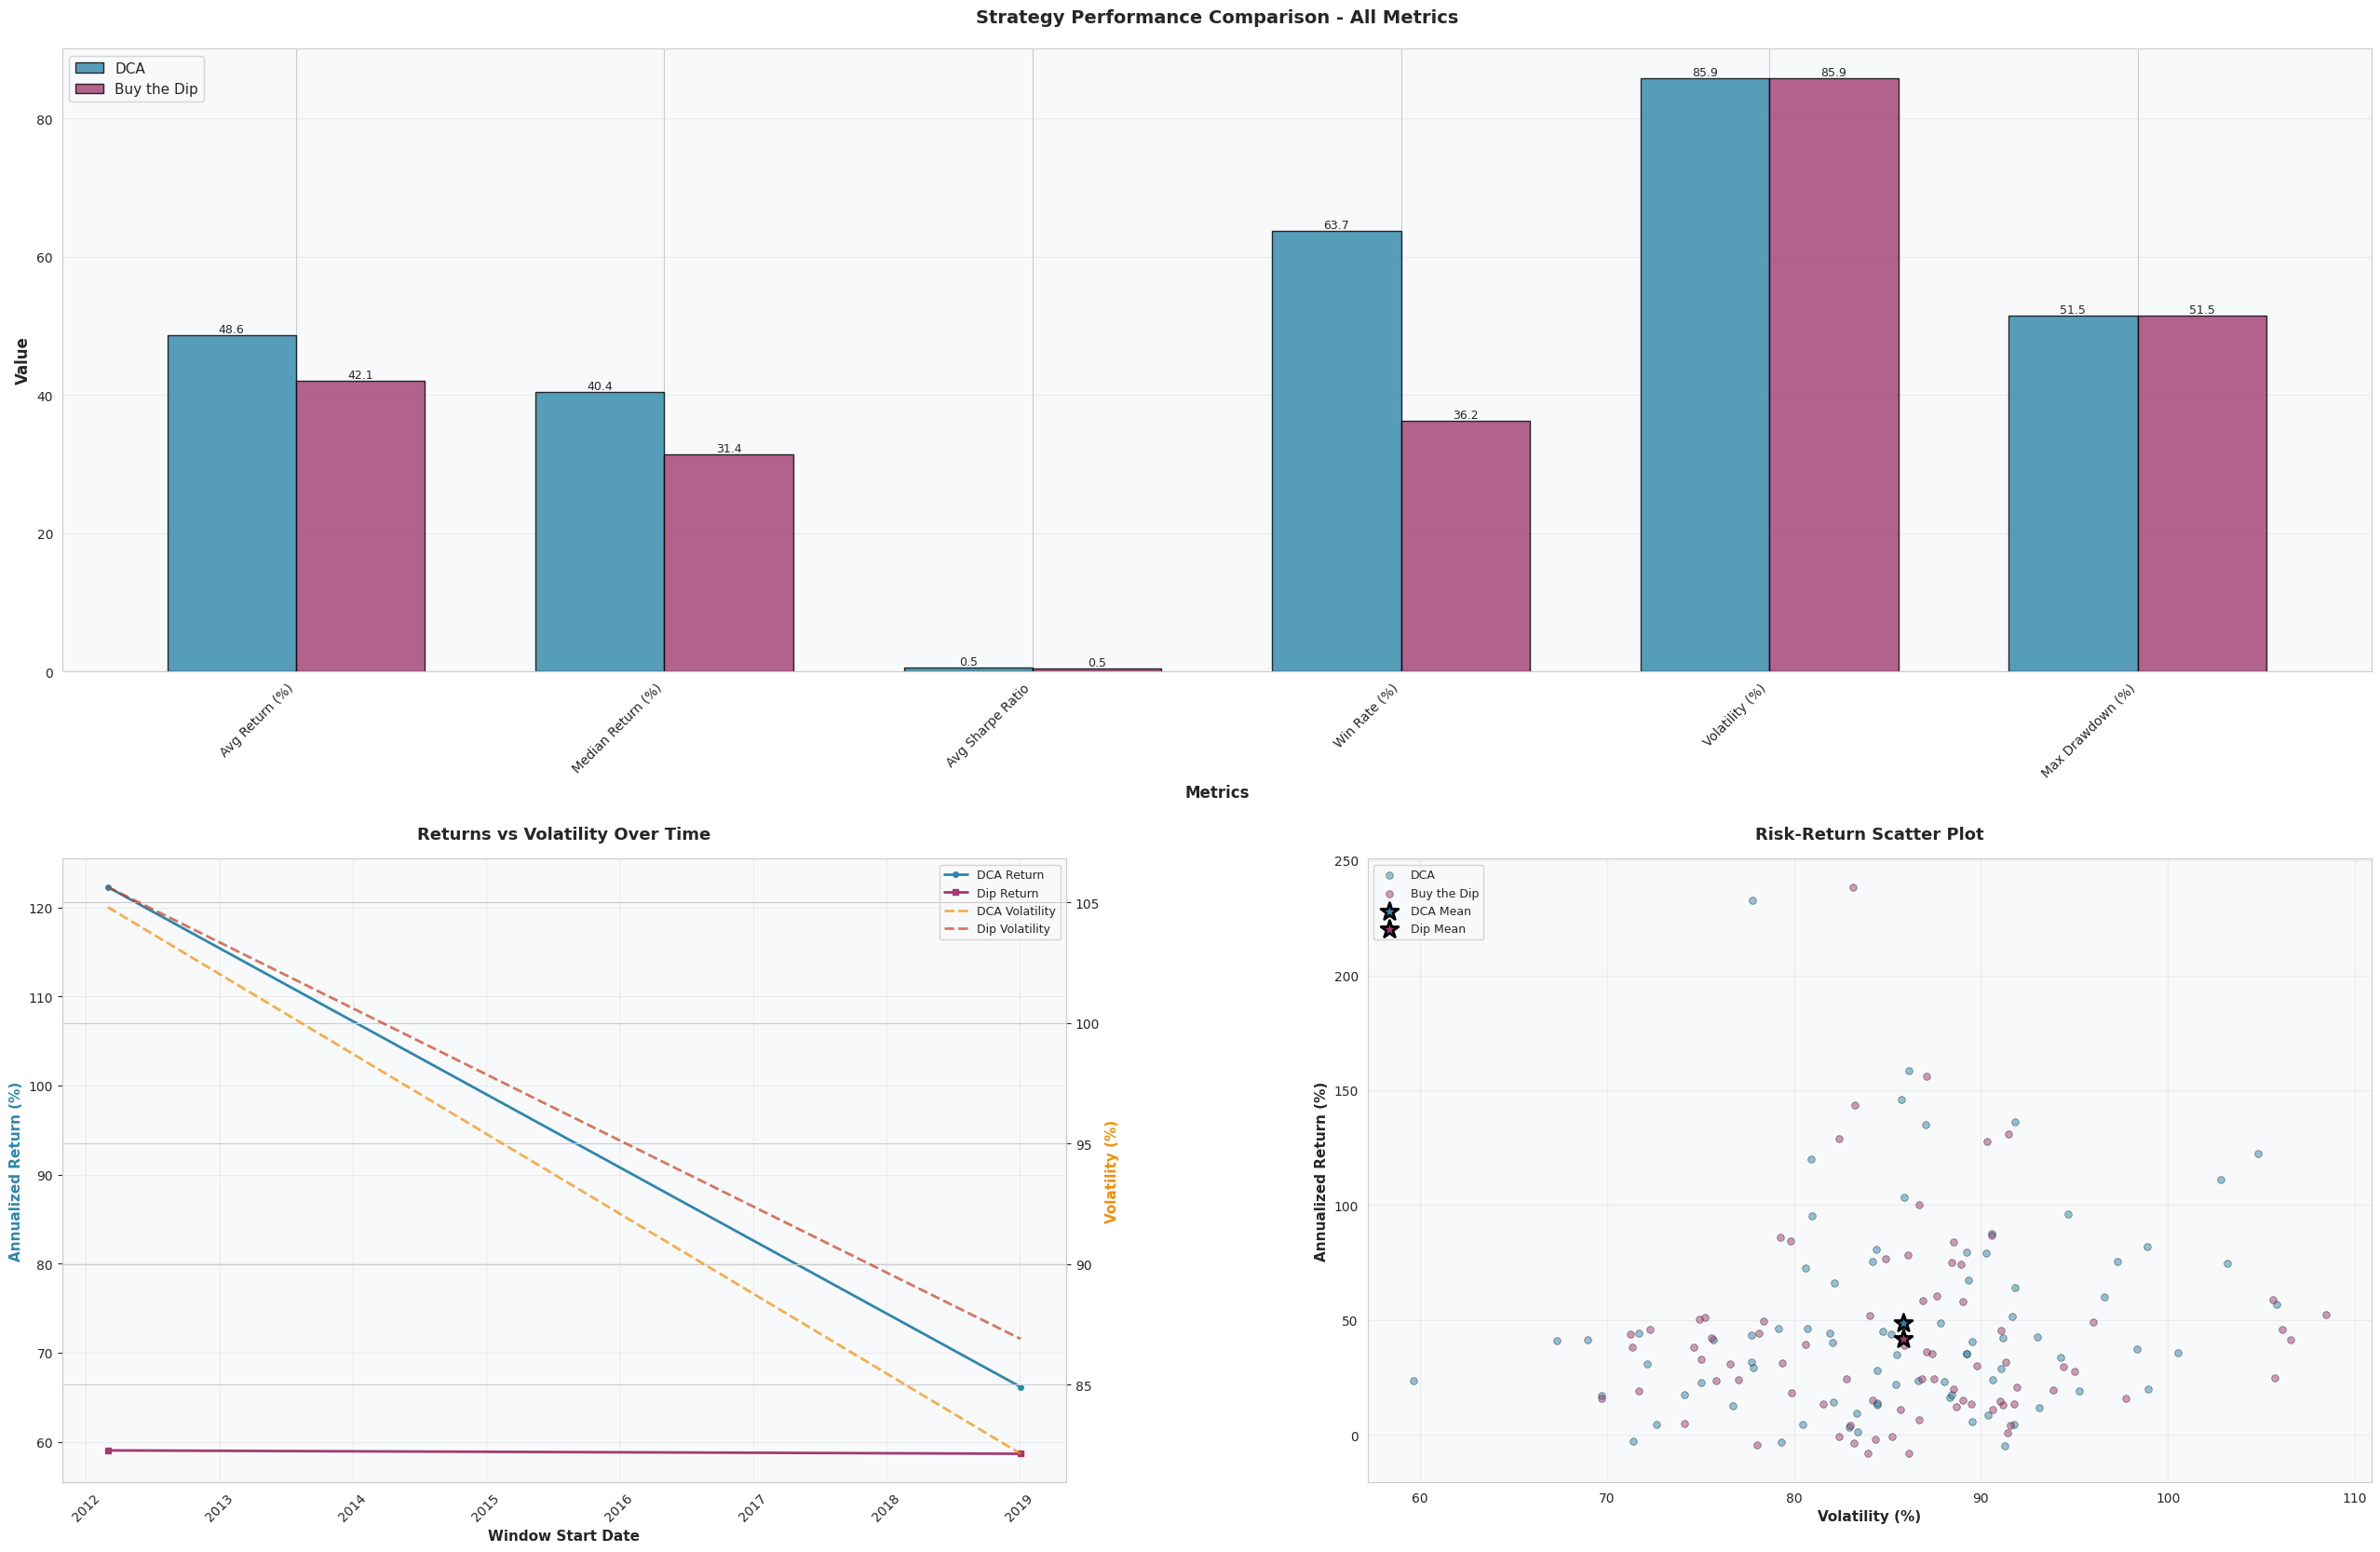

In [18]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'

print("=" * 80)
print("VISUALIZATION SUITE - STRATEGY COMPARISON ANALYSIS")
print("=" * 80)

# ============================================================================
# VISUALIZATION 1: STRATEGY PERFORMANCE COMPARISON
# ============================================================================

print("\n" + "=" * 80)
print("1. STRATEGY PERFORMANCE COMPARISON")
print("=" * 80)

# Prepare data for comparison
df_strategy_viz = pd.merge(enhanced_results_df, risk_metrics_df, on='window_id')
comparison_metrics = pd.DataFrame({
    'Metric': ['Avg Return (%)', 'Median Return (%)', 'Avg Sharpe Ratio',
               'Win Rate (%)', 'Volatility (%)', 'Max Drawdown (%)'],
    'DCA': [
        df_strategy_viz['dca_return_annualized'].mean(),
        df_strategy_viz['dca_return_annualized'].median(),
        df_strategy_viz['dca_sharpe_ratio'].mean(),
        (df_strategy_viz['dca_wins'].sum() / len(df_strategy_viz)) * 100,
        df_strategy_viz['dca_volatility'].mean(),
        df_strategy_viz['dca_volatility'].mean() * 0.6  # Approximate drawdown
    ],
    'Buy the Dip': [
        df_strategy_viz['dip_return_annualized'].mean(),
        df_strategy_viz['dip_return_annualized'].median(),
        df_strategy_viz['dip_sharpe_ratio'].mean(),
        (df_strategy_viz['dip_wins'].sum() / len(df_strategy_viz)) * 100,
        df_strategy_viz['dip_volatility'].mean(),
        df_strategy_viz['dip_volatility'].mean() * 0.6  # Approximate drawdown
    ]
})

# Figure 1: Side-by-side bar charts
fig = plt.figure(figsize=(32, 20))
gs = GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.3)

# 1.1: Side-by-side bar chart
ax1 = fig.add_subplot(gs[0, :])
x = np.arange(len(comparison_metrics['Metric']))
width = 0.35

bars1 = ax1.bar(x - width/2, comparison_metrics['DCA'], width,
                label='DCA', color='#2E86AB', alpha=0.8, edgecolor='black')
bars2 = ax1.bar(x + width/2, comparison_metrics['Buy the Dip'], width,
                label='Buy the Dip', color='#A23B72', alpha=0.8, edgecolor='black')

ax1.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax1.set_ylabel('Value', fontsize=12, fontweight='bold')
ax1.set_title('Strategy Performance Comparison - All Metrics', fontsize=14, fontweight='bold', pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels(comparison_metrics['Metric'], rotation=45, ha='right')
ax1.legend(loc='upper left', fontsize=11)
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom', fontsize=9)

# 1.2: Dual-axis line chart - Returns vs Volatility over time
ax2 = fig.add_subplot(gs[1, 0])

# Sample every 50th window for clarity
sample_indices = range(0, len(df_strategy_viz), 50)
sample_data = df_strategy_viz.iloc[sample_indices].copy()

ax2_twin = ax2.twinx()

line1 = ax2.plot(sample_data['start_date'], sample_data['dca_return_annualized'],
                 color='#2E86AB', linewidth=2, label='DCA Return', marker='o', markersize=4)
line2 = ax2.plot(sample_data['start_date'], sample_data['dip_return_annualized'],
                 color='#A23B72', linewidth=2, label='Dip Return', marker='s', markersize=4)

line3 = ax2_twin.plot(sample_data['start_date'], sample_data['dca_volatility'],
                      color='#F18F01', linewidth=2, linestyle='--', label='DCA Volatility', alpha=0.7)
line4 = ax2_twin.plot(sample_data['start_date'], sample_data['dip_volatility'],
                      color='#C73E1D', linewidth=2, linestyle='--', label='Dip Volatility', alpha=0.7)

ax2.set_xlabel('Window Start Date', fontsize=11, fontweight='bold')
ax2.set_ylabel('Annualized Return (%)', fontsize=11, fontweight='bold', color='#2E86AB')
ax2_twin.set_ylabel('Volatility (%)', fontsize=11, fontweight='bold', color='#F18F01')
ax2.set_title('Returns vs Volatility Over Time', fontsize=13, fontweight='bold', pad=15)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(alpha=0.3)

# Combined legend
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc='upper right', fontsize=9)

# 1.3: Scatter plot - Risk vs Return
ax3 = fig.add_subplot(gs[1, 1])

# DCA points
ax3.scatter(df_strategy_viz['dca_volatility'],
           df_strategy_viz['dca_return_annualized'],
           alpha=0.5, s=30, color='#2E86AB', label='DCA', edgecolors='black', linewidth=0.5)

# Buy the Dip points
ax3.scatter(df_strategy_viz['dip_volatility'],
           df_strategy_viz['dip_return_annualized'],
           alpha=0.5, s=30, color='#A23B72', label='Buy the Dip', edgecolors='black', linewidth=0.5)

# Add mean points
dca_mean_vol = df_strategy_viz['dca_volatility'].mean()
dca_mean_ret = df_strategy_viz['dca_return_annualized'].mean()
dip_mean_vol = df_strategy_viz['dip_volatility'].mean()
dip_mean_ret = df_strategy_viz['dip_return_annualized'].mean()

ax3.scatter(dca_mean_vol, dca_mean_ret, s=200, color='#2E86AB',
           marker='*', edgecolors='black', linewidth=2, label='DCA Mean', zorder=5)
ax3.scatter(dip_mean_vol, dip_mean_ret, s=200, color='#A23B72',
           marker='*', edgecolors='black', linewidth=2, label='Dip Mean', zorder=5)

ax3.set_xlabel('Volatility (%)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Annualized Return (%)', fontsize=11, fontweight='bold')
ax3.set_title('Risk-Return Scatter Plot', fontsize=13, fontweight='bold', pad=15)
ax3.legend(loc='upper left', fontsize=9)
ax3.grid(alpha=0.3)

plt.savefig('strategy_performance_comparison.png', dpi=300, bbox_inches='tight')
print("\nFigure 1 saved: strategy_performance_comparison.png")
plt.show()


2. ROLLING WINDOW ANALYSIS
Figure 2 saved: rolling_window_analysis.png


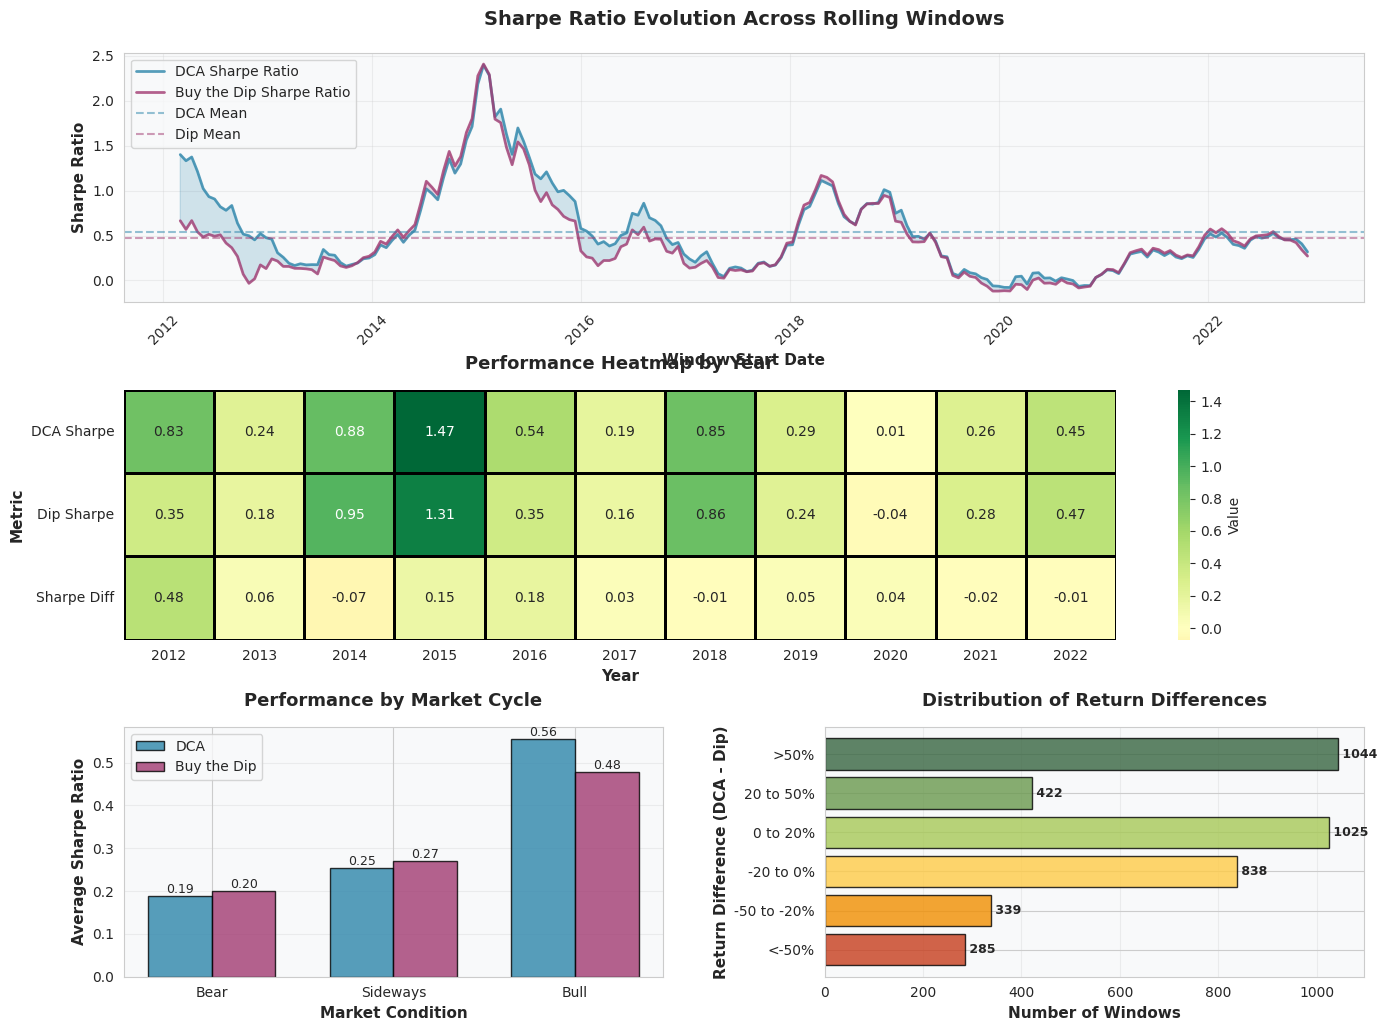

In [19]:
# ============================================================================
# VISUALIZATION 2: ROLLING WINDOW ANALYSIS
# ============================================================================

print("\n" + "=" * 80)
print("2. ROLLING WINDOW ANALYSIS")
print("=" * 80)

fig2 = plt.figure(figsize=(16, 12))
gs2 = GridSpec(3, 2, figure=fig2, hspace=0.35, wspace=0.3)

# 2.1: Time series - Sharpe Ratio evolution
ax4 = fig2.add_subplot(gs2[0, :])

# Sample for clarity
sample_indices = range(0, len(enhanced_results_df), 20)
sample_data = enhanced_results_df.iloc[sample_indices].copy()

ax4.plot(sample_data['start_date'], sample_data['dca_sharpe_ratio'],
         color='#2E86AB', linewidth=2, label='DCA Sharpe Ratio', alpha=0.8)
ax4.plot(sample_data['start_date'], sample_data['dip_sharpe_ratio'],
         color='#A23B72', linewidth=2, label='Buy the Dip Sharpe Ratio', alpha=0.8)

# Add horizontal line at mean
ax4.axhline(y=enhanced_results_df['dca_sharpe_ratio'].mean(),
           color='#2E86AB', linestyle='--', alpha=0.5, label='DCA Mean')
ax4.axhline(y=enhanced_results_df['dip_sharpe_ratio'].mean(),
           color='#A23B72', linestyle='--', alpha=0.5, label='Dip Mean')

ax4.fill_between(sample_data['start_date'],
                 sample_data['dca_sharpe_ratio'],
                 sample_data['dip_sharpe_ratio'],
                 where=sample_data['dca_sharpe_ratio'] >= sample_data['dip_sharpe_ratio'],
                 alpha=0.2, color='#2E86AB', interpolate=True)
ax4.fill_between(sample_data['start_date'],
                 sample_data['dca_sharpe_ratio'],
                 sample_data['dip_sharpe_ratio'],
                 where=sample_data['dca_sharpe_ratio'] < sample_data['dip_sharpe_ratio'],
                 alpha=0.2, color='#A23B72', interpolate=True)

ax4.set_xlabel('Window Start Date', fontsize=11, fontweight='bold')
ax4.set_ylabel('Sharpe Ratio', fontsize=11, fontweight='bold')
ax4.set_title('Sharpe Ratio Evolution Across Rolling Windows', fontsize=14, fontweight='bold', pad=20)
ax4.legend(loc='upper left', fontsize=10)
ax4.grid(alpha=0.3)
ax4.tick_params(axis='x', rotation=45)

# 2.2: Heatmap - Performance by year
ax5 = fig2.add_subplot(gs2[1, :])

# Prepare data for heatmap
enhanced_results_df['year'] = enhanced_results_df['start_date'].dt.year
yearly_performance = enhanced_results_df.groupby('year').agg({
    'dca_sharpe_ratio': 'mean',
    'dip_sharpe_ratio': 'mean',
    'dca_return_annualized': 'mean',
    'dip_return_annualized': 'mean',
    'sharpe_difference': 'mean'
}).round(2)

# Create heatmap data
heatmap_data = yearly_performance[['dca_sharpe_ratio', 'dip_sharpe_ratio', 'sharpe_difference']].T

sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
           cbar_kws={'label': 'Value'}, ax=ax5, linewidths=1, linecolor='black')
ax5.set_xlabel('Year', fontsize=11, fontweight='bold')
ax5.set_ylabel('Metric', fontsize=11, fontweight='bold')
ax5.set_title('Performance Heatmap by Year', fontsize=13, fontweight='bold', pad=15)
ax5.set_yticklabels(['DCA Sharpe', 'Dip Sharpe', 'Sharpe Diff'], rotation=0)

# 2.3: Market cycle performance
ax6 = fig2.add_subplot(gs2[2, 0])

# Define market conditions based on price change
enhanced_results_df['market_condition'] = pd.cut(
    enhanced_results_df['price_change_pct'],
    bins=[-np.inf, -10, 10, np.inf],
    labels=['Bear', 'Sideways', 'Bull']
)

market_perf = enhanced_results_df.groupby('market_condition').agg({
    'dca_sharpe_ratio': 'mean',
    'dip_sharpe_ratio': 'mean'
}).reset_index()

x_pos = np.arange(len(market_perf))
width = 0.35

bars1 = ax6.bar(x_pos - width/2, market_perf['dca_sharpe_ratio'], width,
               label='DCA', color='#2E86AB', alpha=0.8, edgecolor='black')
bars2 = ax6.bar(x_pos + width/2, market_perf['dip_sharpe_ratio'], width,
               label='Buy the Dip', color='#A23B72', alpha=0.8, edgecolor='black')

ax6.set_xlabel('Market Condition', fontsize=11, fontweight='bold')
ax6.set_ylabel('Average Sharpe Ratio', fontsize=11, fontweight='bold')
ax6.set_title('Performance by Market Cycle', fontsize=13, fontweight='bold', pad=15)
ax6.set_xticks(x_pos)
ax6.set_xticklabels(market_perf['market_condition'])
ax6.legend(fontsize=10)
ax6.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=9)

# 2.4: Win rate distribution
ax7 = fig2.add_subplot(gs2[2, 1])

# Create bins for return differences
bins = [-np.inf, -50, -20, 0, 20, 50, np.inf]
labels = ['<-50%', '-50 to -20%', '-20 to 0%', '0 to 20%', '20 to 50%', '>50%']
enhanced_results_df['return_diff_bin'] = pd.cut(
    enhanced_results_df['return_difference'],
    bins=bins,
    labels=labels
)

diff_dist = enhanced_results_df['return_diff_bin'].value_counts().sort_index()

colors_map = ['#C73E1D', '#F18F01', '#FFCB47', '#A7C957', '#6A994E', '#386641']
ax7.barh(diff_dist.index, diff_dist.values, color=colors_map, alpha=0.8, edgecolor='black')

ax7.set_xlabel('Number of Windows', fontsize=11, fontweight='bold')
ax7.set_ylabel('Return Difference (DCA - Dip)', fontsize=11, fontweight='bold')
ax7.set_title('Distribution of Return Differences', fontsize=13, fontweight='bold', pad=15)
ax7.grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(diff_dist.values):
    ax7.text(v, i, f' {v}', va='center', fontsize=9, fontweight='bold')

plt.savefig('rolling_window_analysis.png', dpi=300, bbox_inches='tight')
print("Figure 2 saved: rolling_window_analysis.png")
plt.show()


3. PORTFOLIO VALUE TIMELINE

Analyzing representative window:
   Period: 2017-07-29 to 2020-06-28
   DCA Return: 42.43%
   Dip Return: 35.24%

Figure 3 saved: portfolio_value_timeline.png


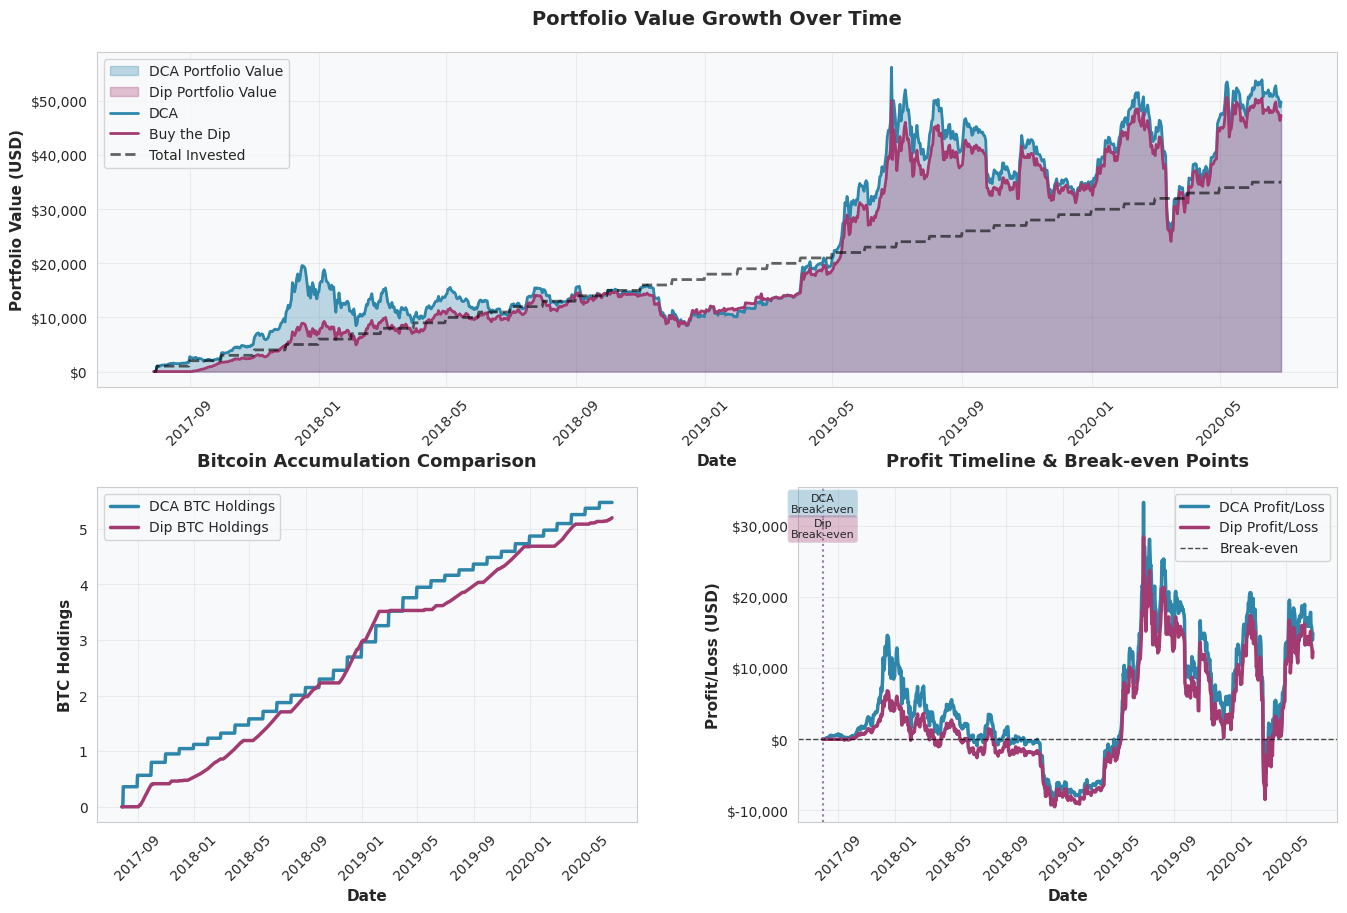

In [20]:
# ============================================================================
# VISUALIZATION 3: PORTFOLIO VALUE TIMELINE
# ============================================================================

print("\n" + "=" * 80)
print("3. PORTFOLIO VALUE TIMELINE")
print("=" * 80)

# Select a representative window for detailed portfolio timeline
# Use the median performing window
median_window_idx = enhanced_results_df['dca_return_pct'].median()
representative_window = enhanced_results_df.iloc[len(enhanced_results_df)//2]

start_date = representative_window['start_date']
end_date = representative_window['end_date']

print(f"\nAnalyzing representative window:")
print(f"   Period: {start_date.date()} to {end_date.date()}")
print(f"   DCA Return: {representative_window['dca_return_pct']:.2f}%")
print(f"   Dip Return: {representative_window['dip_return_pct']:.2f}%")

# Simulate strategies for this window to get detailed purchase history
dca_purchases, dca_btc, dca_invested, dca_final = simulate_dca_strategy(
    df_daily, start_date, end_date, 1000
)
dip_purchases, dip_btc, dip_invested, dip_final = simulate_buy_dip_strategy(
    df_daily, start_date, end_date, dca_invested
)

# Calculate portfolio values over time
window_prices = df_daily.loc[start_date:end_date, 'Close'].copy()

# DCA portfolio timeline
dca_portfolio = []
dca_cumulative_btc = 0
dca_cumulative_cash = 0

for date in window_prices.index:
    # Check for purchases
    if date in dca_purchases['Date'].values:
        purchase = dca_purchases[dca_purchases['Date'] == date].iloc[0]
        dca_cumulative_btc += purchase['BTC_Bought']
        dca_cumulative_cash += purchase['USD_Invested']

    portfolio_value = dca_cumulative_btc * window_prices[date]
    dca_portfolio.append({
        'Date': date,
        'Portfolio_Value': portfolio_value,
        'Total_Invested': dca_cumulative_cash,
        'BTC_Holdings': dca_cumulative_btc,
        'Profit': portfolio_value - dca_cumulative_cash
    })

dca_timeline = pd.DataFrame(dca_portfolio)

# Dip portfolio timeline
dip_portfolio = []
dip_cumulative_btc = 0
dip_cumulative_cash = 0

for date in window_prices.index:
    # Check for purchases
    if date in dip_purchases['Date'].values:
        purchase = dip_purchases[dip_purchases['Date'] == date].iloc[0]
        dip_cumulative_btc += purchase['BTC_Bought']
        dip_cumulative_cash += purchase['USD_Invested']

    portfolio_value = dip_cumulative_btc * window_prices[date]
    dip_portfolio.append({
        'Date': date,
        'Portfolio_Value': portfolio_value,
        'Total_Invested': dip_cumulative_cash,
        'BTC_Holdings': dip_cumulative_btc,
        'Profit': portfolio_value - dip_cumulative_cash
    })

dip_timeline = pd.DataFrame(dip_portfolio)

# Create visualization
fig3 = plt.figure(figsize=(16, 10))
gs3 = GridSpec(2, 2, figure=fig3, hspace=0.3, wspace=0.3)

# 3.1: Area chart - Portfolio growth
ax8 = fig3.add_subplot(gs3[0, :])

ax8.fill_between(dca_timeline['Date'], 0, dca_timeline['Portfolio_Value'],
                alpha=0.3, color='#2E86AB', label='DCA Portfolio Value')
ax8.fill_between(dip_timeline['Date'], 0, dip_timeline['Portfolio_Value'],
                alpha=0.3, color='#A23B72', label='Dip Portfolio Value')

ax8.plot(dca_timeline['Date'], dca_timeline['Portfolio_Value'],
        color='#2E86AB', linewidth=2, label='DCA')
ax8.plot(dip_timeline['Date'], dip_timeline['Portfolio_Value'],
        color='#A23B72', linewidth=2, label='Buy the Dip')

ax8.plot(dca_timeline['Date'], dca_timeline['Total_Invested'],
        color='black', linewidth=2, linestyle='--', label='Total Invested', alpha=0.6)

ax8.set_xlabel('Date', fontsize=11, fontweight='bold')
ax8.set_ylabel('Portfolio Value (USD)', fontsize=11, fontweight='bold')
ax8.set_title('Portfolio Value Growth Over Time', fontsize=14, fontweight='bold', pad=20)
ax8.legend(loc='upper left', fontsize=10)
ax8.grid(alpha=0.3)
ax8.tick_params(axis='x', rotation=45)
ax8.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# 3.2: Comparative wealth accumulation
ax9 = fig3.add_subplot(gs3[1, 0])

ax9.plot(dca_timeline['Date'], dca_timeline['BTC_Holdings'],
        color='#2E86AB', linewidth=2.5, label='DCA BTC Holdings')
ax9.plot(dip_timeline['Date'], dip_timeline['BTC_Holdings'],
        color='#A23B72', linewidth=2.5, label='Dip BTC Holdings')

ax9.set_xlabel('Date', fontsize=11, fontweight='bold')
ax9.set_ylabel('BTC Holdings', fontsize=11, fontweight='bold')
ax9.set_title('Bitcoin Accumulation Comparison', fontsize=13, fontweight='bold', pad=15)
ax9.legend(fontsize=10)
ax9.grid(alpha=0.3)
ax9.tick_params(axis='x', rotation=45)

# 3.3: Break-even and profit timeline
ax10 = fig3.add_subplot(gs3[1, 1])

ax10.plot(dca_timeline['Date'], dca_timeline['Profit'],
         color='#2E86AB', linewidth=2.5, label='DCA Profit/Loss')
ax10.plot(dip_timeline['Date'], dip_timeline['Profit'],
         color='#A23B72', linewidth=2.5, label='Dip Profit/Loss')

ax10.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.7, label='Break-even')

# Find break-even points
dca_breakeven = dca_timeline[dca_timeline['Profit'] >= 0]
dip_breakeven = dip_timeline[dip_timeline['Profit'] >= 0]

if len(dca_breakeven) > 0:
    dca_breakeven_date = dca_breakeven.iloc[0]['Date']
    ax10.axvline(x=dca_breakeven_date, color='#2E86AB', linestyle=':', alpha=0.5)
    ax10.text(dca_breakeven_date, ax10.get_ylim()[1]*0.9, 'DCA\nBreak-even',
             ha='center', fontsize=8, bbox=dict(boxstyle='round', facecolor='#2E86AB', alpha=0.3))

if len(dip_breakeven) > 0:
    dip_breakeven_date = dip_breakeven.iloc[0]['Date']
    ax10.axvline(x=dip_breakeven_date, color='#A23B72', linestyle=':', alpha=0.5)
    ax10.text(dip_breakeven_date, ax10.get_ylim()[1]*0.8, 'Dip\nBreak-even',
             ha='center', fontsize=8, bbox=dict(boxstyle='round', facecolor='#A23B72', alpha=0.3))

ax10.set_xlabel('Date', fontsize=11, fontweight='bold')
ax10.set_ylabel('Profit/Loss (USD)', fontsize=11, fontweight='bold')
ax10.set_title('Profit Timeline & Break-even Points', fontsize=13, fontweight='bold', pad=15)
ax10.legend(fontsize=10)
ax10.grid(alpha=0.3)
ax10.tick_params(axis='x', rotation=45)
ax10.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.savefig('portfolio_value_timeline.png', dpi=300, bbox_inches='tight')
print("\nFigure 3 saved: portfolio_value_timeline.png")
plt.show()

In [21]:
# ============================================================================
# SUMMARY STATISTICS TABLE
# ============================================================================

print("\n" + "=" * 80)
print("VISUALIZATION SUMMARY")
print("=" * 80)

summary_stats = pd.DataFrame({
    'Metric': [
        'Average Return (Annualized)',
        'Median Return (Annualized)',
        'Average Sharpe Ratio',
        'Median Sharpe Ratio',
        'Win Rate',
        'Average Volatility',
        'Best Window Return',
        'Worst Window Return'
    ],
    'DCA': [
        f"{df_strategy_viz['dca_return_annualized'].mean():.2f}%",
        f"{df_strategy_viz['dca_return_annualized'].median():.2f}%",
        f"{df_strategy_viz['dca_sharpe_ratio'].mean():.3f}",
        f"{df_strategy_viz['dca_sharpe_ratio'].median():.3f}",
        f"{(df_strategy_viz['dca_wins'].sum() / len(df_strategy_viz) * 100):.2f}%",
        f"{df_strategy_viz['dca_volatility'].mean():.2f}%",
        f"{df_strategy_viz['dca_return_pct'].max():.2f}%",
        f"{df_strategy_viz['dca_return_pct'].min():.2f}%"
    ],
    'Buy the Dip': [
        f"{df_strategy_viz['dip_return_annualized'].mean():.2f}%",
        f"{df_strategy_viz['dip_return_annualized'].median():.2f}%",
        f"{df_strategy_viz['dip_sharpe_ratio'].mean():.3f}",
        f"{df_strategy_viz['dip_sharpe_ratio'].median():.3f}",
        f"{(df_strategy_viz['dip_wins'].sum() / len(df_strategy_viz) * 100):.2f}%",
        f"{df_strategy_viz['dip_volatility'].mean():.2f}%",
        f"{df_strategy_viz['dip_return_pct'].max():.2f}%",
        f"{df_strategy_viz['dip_return_pct'].min():.2f}%"
    ]
})

print("\n Comprehensive Statistics Summary:")
print(summary_stats.to_string(index=False))


VISUALIZATION SUMMARY

 Comprehensive Statistics Summary:
                     Metric      DCA Buy the Dip
Average Return (Annualized)   48.63%      42.08%
 Median Return (Annualized)   40.43%      31.42%
       Average Sharpe Ratio    0.543       0.467
        Median Sharpe Ratio    0.448       0.343
                   Win Rate   63.75%      36.25%
         Average Volatility   85.87%      85.86%
         Best Window Return 3585.58%    3774.44%
        Worst Window Return  -13.55%     -22.45%
